In [2]:
%matplotlib widget
import warnings
import inspect
import matplotlib.pyplot as plt
import IPython.display
import numpy as np
from cued_sf2_lab.familiarisation import load_mat_img, plot_image
from cued_sf2_lab.dct import colxfm

# 8 The Lapped Bi-orthogonal Transform (LBT)

<!-- sorry for the nasty HTML, markdown is bad for figures -->

<figure style="text-align: center">
<div class="row">
<figure class="col-md-4 col-md-offset-1">
<img src="figures/lbt.png" style="max-height: 350px" />
<figcaption>(a) Lapped Bi-orthogonal Transform</figcaption>
</figure>

<figure class="col-md-5 col-md-offset-1">
<img src="figures/pot.png" style="max-height: 350px" />
<figcaption>(b) Photo Overlap Transform and a DCT</figcaption>
</figure>
</div>
<div class="row">
<figcaption>
<br />

Figure 4: (a) An LBT transforms overlapping sections of X to create Y. (b) In some cases
this can be interpreted as pre-filtering with a POT, followed by a DCT.</figcaption></div></figure>

One of the difficulties with the DCT is that it processes each block separately and hence
does not take advantage of any correlation between blocks. A possible solution to this is
to use a _Lapped Bi-orthogonal Transform (LBT)_. These transform overlapping blocks in `X`
to generate smaller non-overlapping blocks in `Y`. In the left-hand figure above, 16 values
in `X` are used to generate each set of 8 values in `Y`.

LBTs are quite complicated to derive and analyse: however one of the most popular forms<sup>3</sup>
can also be represented as a pre-filtering operation before performing the DCT described
in the previous section.
In this case the pre-filtering (or post-filtering for the reverse
operation) is sometimes known as a _Photo Overlap Transform or POT_. A POT followed
by a DCT is then equivalent to a particular type of LBT.

The right-hand figure above demonstrates this. The POT is first performed on a section
of data `X`, shifted by `N/2`, so that it runs across the block boundaries of the subsequent
DCT. Ignoring this block shift for a moment, the forward operation for a 2D image `X` is:


$$Y = C ∗ Pf ∗ X ∗ Pf ′ ∗ C′$$

or in reverse

$$ X = Pr′ ∗ C′ ∗ Y ∗ C ∗ Pr $$

<hr />
<small><sup>3</sup>The type-II fast lapped (bi-)orthogonal transform, or LOT-II</small>

## 8.1 Applying the LBT to images

In [3]:
X, cmaps_dict = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})
X = X - 128.0

The pre-filtering `Pf ∗ X ∗ Pf′` (with the correct block shift) is straightforward in Python:

```python
t = np.s_[N//2:-N//2]  # N is the DCT size, I is the image size
Xp = X.copy()  # copy the non-transformed edges directly from X
Xp[t,:] = colxfm(Xp[t,:], Pf)
Xp[:,t] = colxfm(Xp[:,t].T, Pf).T
```

This is followed by the DCT `C` as before. In the reverse operation, the inverse DCT `C’` is
performed first, followed by Pr’:
```python
Zp = Z.copy()  #copy the non-transformed edges directly from Z
Zp[:,t] = colxfm(Zp[:,t].T, Pr.T).T
Zp[t,:] = colxfm(Zp[t,:], Pr.T)
```

We have provided a function `pot_ii(N, s)` which will generate a forward (pre-filtering,
`Pf`) and reverse (post-filtering, `Pr`) matrix of size `N` with scaling factor `s`.

In [4]:
from cued_sf2_lab.lbt import pot_ii

Edit your code
for performing DCT analysis so that it can pre-filter `X` with `Pf` before the forward DCT,
then post-filter `Z` with `Pr` after the inverse DCT. Confirm that, without quantisation, this
correctly recreates the original image, i.e. `Zp = X`. Use `Pf, Pr = pot_ii(N)` with the
default scaling value `s`.

In [5]:
# your code here
from cued_sf2_lab.dct import dct_ii
from cued_sf2_lab.laplacian_pyramid import quantise

C8 = dct_ii(8)

def forward_lbt(X,s=1, N=8):
    Pf, Pr = pot_ii(N,s)
    t = np.s_[N//2:-N//2]  # N is the DCT size, I is the image size
    Xp = X.copy()  # copy the non-transformed edges directly from X
    Xp[t,:] = colxfm(Xp[t,:], Pf)
    Xp[:,t] = colxfm(Xp[:,t].T, Pf).T
    return Xp

def inverse_lbt(Zp,s=1, N=8):
    Pf, Pr = pot_ii(N,s)
    t = np.s_[N//2:-N//2]  # N is the DCT size, I is the image size
    Z = Zp.copy()  #copy the non-transformed edges directly from Z
    Z[:,t] = colxfm(Z[:,t].T, Pr.T).T
    Z[t,:] = colxfm(Z[t,:], Pr.T)
    return Z

"""


Xp = forward_lbt(X, s=2)

Y = colxfm(colxfm(Xp, C8).T, C8).T

#Y = quantise(Y, step=23.3)

Zp = colxfm(colxfm(Y.T, C8.T).T, C8.T)

Z = inverse_lbt(Zp, s=2)

fig, ax = plt.subplots(1, 2)
plot_image(X, ax=ax[0], cmap=cmaps_dict['map'])
plot_image(Z, ax=ax[1], cmap=cmaps_dict['map'])
ax[0].set_title('Original Image')
ax[1].set_title('DCT of Image')
plt.show()

print(abs(X - Z).max())
print(np.sqrt(np.mean((Z - X)**2)))
"""



"\n\n\nXp = forward_lbt(X, s=2)\n\nY = colxfm(colxfm(Xp, C8).T, C8).T\n\n#Y = quantise(Y, step=23.3)\n\nZp = colxfm(colxfm(Y.T, C8.T).T, C8.T)\n\nZ = inverse_lbt(Zp, s=2)\n\nfig, ax = plt.subplots(1, 2)\nplot_image(X, ax=ax[0], cmap=cmaps_dict['map'])\nplot_image(Z, ax=ax[1], cmap=cmaps_dict['map'])\nax[0].set_title('Original Image')\nax[1].set_title('DCT of Image')\nplt.show()\n\nprint(abs(X - Z).max())\nprint(np.sqrt(np.mean((Z - X)**2)))\n"

## 8.2 Quantisation and coding efficiency

The scaling factor `s` determines the degree of bi-orthogonality. If `s = 1` then Pf is the same
as Pr, otherwise `1 < s < 2` weights the relative contributions of `Pf` and `Pr` un-equally.

<div class="alert alert-block alert-danger">

For an 8 × 8 DCT, try implementing an LBT with POT scaling factors varying from $1$
to $2$ ($\sqrt{2}$ is often a good choice). In each case find the quantisation step which makes
the rms error match the directly quantised image. Note the compression ratios and find
the scaling factor which maximises these. Also note the visual features in these images.</div>

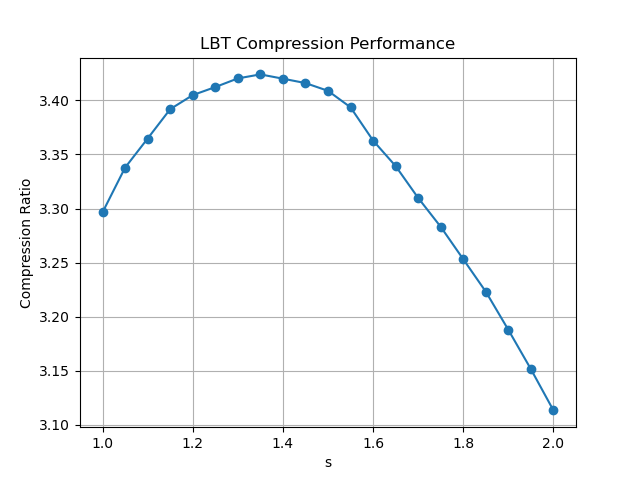

s=1.000 step=23.362 rms=4.860 ratio=3.296
s=1.050 step=23.796 rms=4.860 ratio=3.338
s=1.100 step=24.191 rms=4.860 ratio=3.365
s=1.150 step=24.543 rms=4.860 ratio=3.392
s=1.200 step=24.852 rms=4.860 ratio=3.405
s=1.250 step=25.156 rms=4.860 ratio=3.412
s=1.300 step=25.430 rms=4.860 ratio=3.420
s=1.350 step=25.649 rms=4.860 ratio=3.424
s=1.400 step=25.866 rms=4.860 ratio=3.420
s=1.450 step=26.028 rms=4.860 ratio=3.416
s=1.500 step=26.221 rms=4.860 ratio=3.409
s=1.550 step=26.339 rms=4.860 ratio=3.394
s=1.600 step=26.357 rms=4.859 ratio=3.363
s=1.650 step=26.410 rms=4.860 ratio=3.339
s=1.700 step=26.452 rms=4.860 ratio=3.310
s=1.750 step=26.528 rms=4.860 ratio=3.283
s=1.800 step=26.543 rms=4.860 ratio=3.253
s=1.850 step=26.554 rms=4.860 ratio=3.223
s=1.900 step=26.533 rms=4.860 ratio=3.188
s=1.950 step=26.491 rms=4.860 ratio=3.151
s=2.000 step=26.443 rms=4.861 ratio=3.113

Best s = 1.350
Best step = 25.649
RMS error = 4.860
Maximum compression ratio = 3.424


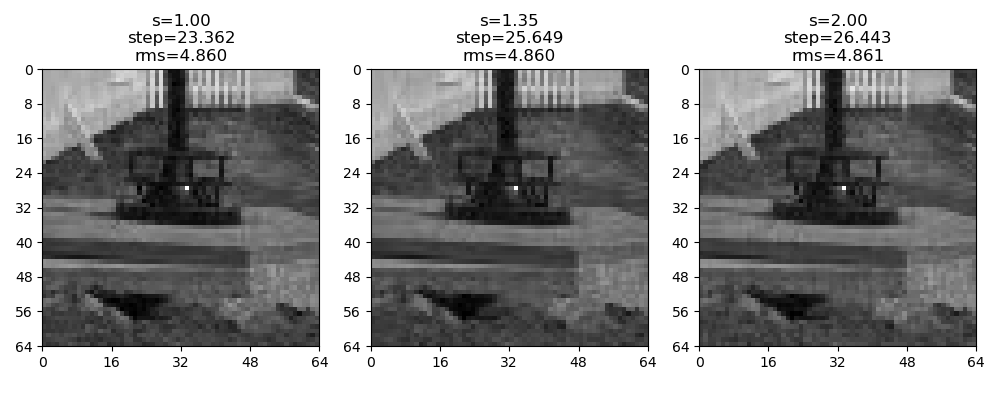

In [20]:
# your code here
from scipy.optimize import minimize_scalar

from cued_sf2_lab.laplacian_pyramid import bpp
from cued_sf2_lab.laplacian_pyramid import quantise
from cued_sf2_lab.dct import regroup

def dctbpp(Yr, N):
    bits = 0
    step_size = Yr.shape[0] // N
    # split Yr in NxN blocks and calculate the bpp for each block
    for i in range(0, Yr.shape[0], step_size):
        for j in range(0, Yr.shape[1], step_size):
            block = Yr[i:i+step_size, j:j+step_size]
            bits += bpp(block) * step_size**2
    return bits

target_rms = 4.86

def optimise_step(Cn, target_rms, bounds=(1.0, 60.0), s=1):
    def rms_for_step(step):
        Xps = forward_lbt(X, s, N=len(Cn))
        Ys = colxfm(colxfm(Xps, Cn).T, Cn).T
        Yq = quantise(Ys, step)
        Zps = colxfm(colxfm(Yq.T, Cn.T).T, Cn.T)
        Zqs = inverse_lbt(Zps, s, N=len(Cn))

        return np.sqrt(np.mean((X - Zqs)**2))

    def objective(step):
        return abs(rms_for_step(step) - target_rms)

    result = minimize_scalar(objective, bounds=bounds, method='bounded')
    return result.x, rms_for_step(result.x)

def compression_ratio(Cn, step, s):
    Xps = forward_lbt(X, s, N=len(Cn))
    Ys = colxfm(colxfm(Xps, Cn).T, Cn).T
    Yq = quantise(Ys, step)
    Yr = regroup(Yq, len(Cn))
    bitsdct = dctbpp(Yr, 16)

    Xq = quantise(X, 17)
    bitsdirect = bpp(Xq)*(Xq.shape[0]*Xq.shape[1])

    return bitsdirect / bitsdct

s_values = np.linspace(1.0, 2.0, 21)
results = []

for s in s_values:
    step, rms = optimise_step(C8, target_rms, s=s)
    ratio = compression_ratio(C8, step, s=s)
    results.append((s, step, rms, ratio))

fig2, ax2 = plt.subplots()
ax2.plot([r[0] for r in results], [r[3] for r in results], marker='o')
ax2.set_xlabel('s')
ax2.set_ylabel('Compression Ratio')
ax2.set_title('LBT Compression Performance')
ax2.grid(True)
plt.show()

best_s, best_step, best_rms, best_ratio = max(results, key=lambda item: item[3])

for s, step, rms, ratio in results:
    print(f's={s:.3f} step={step:.3f} rms={rms:.3f} ratio={ratio:.3f}')

print()
print(f'Best s = {best_s:.3f}')
print(f'Best step = {best_step:.3f}')
print(f'RMS error = {best_rms:.3f}')
print(f'Maximum compression ratio = {best_ratio:.3f}')

s_list = [1.0, 1.35, 2.0]

fig, axes = plt.subplots(1, len(s_list), figsize=(10, 4))

for ax, s in zip(axes, s_list):
    step, rms = optimise_step(C8, target_rms, s=s)
    Xps = forward_lbt(X, s=s, N=8)
    Ys = colxfm(colxfm(Xps, C8).T, C8).T
    Yq = quantise(Ys, step)
    Zps = colxfm(colxfm(Yq.T, C8.T).T, C8.T)
    Z = inverse_lbt(Zps, s=s, N=8)

    plot_image(Z[192:256, 192:256], ax=ax, cmap=cmaps_dict['map'])
    ax.set_title(f's={s:.2f}\nstep={step:.3f}\nrms={rms:.3f}')

plt.tight_layout()
plt.show()



The POT can often improve both compression and block smoothing, since the pre-filter
acts to reduce correlations between each DCT sub-block, whilst the inverse post-filter
acts to remove the discontinuities between sub-blocks. This is rather different from the
operation of the DCT. Investigate this by looking at the basis functions, as you did with
the DCT:

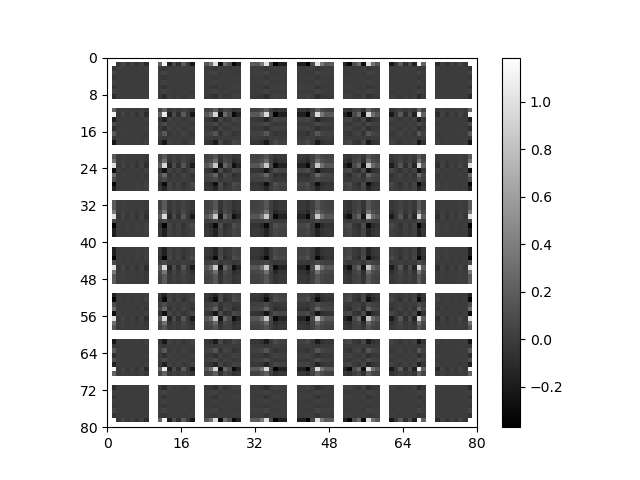

In [21]:
Pf, Pr = pot_ii(8)
bases = np.concatenate([np.full((8,1), np.nan), Pf, np.full((8,1), np.nan)], axis=1)
bases = bases.reshape(-1, 1)
fig, ax = plt.subplots()
im_obj = plot_image(bases @ bases.T, ax=ax)
fig.colorbar(im_obj, ax=ax)

<div class="alert alert-block alert-danger">

Look at both these bases and the pre-filtered image `Xp`, using different scaling factors
`s`, and comment on the visual effect of varying these scaling factors. You may need to
multiply `Xp` by up to 0.5 to display it better.</div>

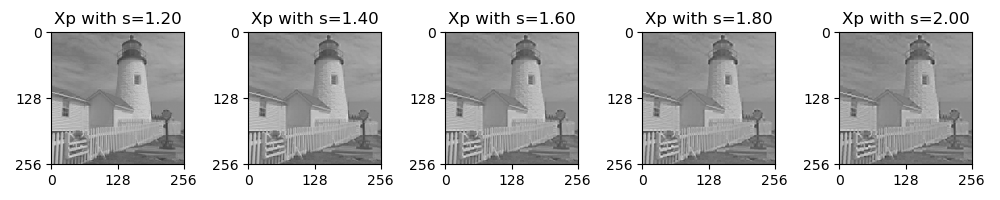

In [22]:
# your code here
Xp = []
for i in range(1,6):
    Xp.append(forward_lbt(X, s=(1+i/5))*0.5)

    n = len(Xp)
fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
if n == 1:
    axes = [axes]
for idx, (ax, img) in enumerate(zip(axes, Xp)):
    plot_image(img * 0.5, ax=ax, cmap=cmaps_dict['map'])
    ax.set_title(f'Xp with s={1+(idx+1)/5:.2f}')

plt.tight_layout()
plt.show()

With this type of POT / DCT combination it is common to use smaller DCT block sizes
but to code several blocks together. Hence a more accurate estimate of the number of bits
is found by always using 16 × 16 blocks, i.e. regroup `Yq` with the correct size `N` to give
`Yr`, but then always use `dctbpp(Yr, 16)`.

<div class="alert alert-block alert-danger">

Investigate the relative visual and compression performance of LBTs with 4 × 4, 8 × 8
and 16 × 16 blocks, using the scaling factor you have previously selected. As before, be
careful to match the rms error with a directly quantised image.</div>

Optimised step size for s=1.350: 25.649 with RMS error 4.860
3.4241285751603394
4
4×4: step=28.855, rms=4.860, ratio=3.564
8
8×8: step=25.945, rms=4.860, ratio=3.423
16
16×16: step=22.935, rms=4.860, ratio=2.944


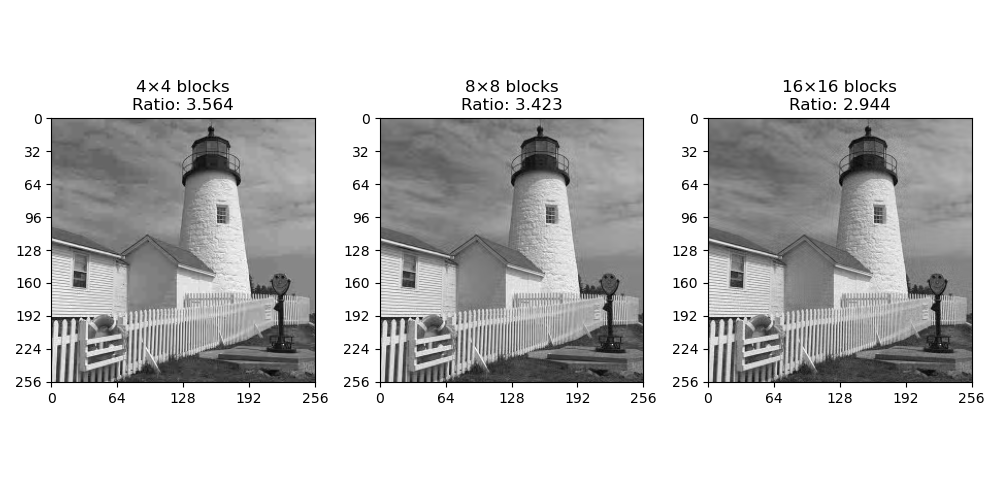

In [23]:
# your code here
# your code here
from scipy.optimize import minimize_scalar

from cued_sf2_lab.laplacian_pyramid import bpp
from cued_sf2_lab.laplacian_pyramid import quantise
from cued_sf2_lab.dct import regroup

n, rms = optimise_step(C8, target_rms, s=1.350)
print(f'Optimised step size for s=1.350: {n:.3f} with RMS error {rms:.3f}')   
print(compression_ratio(C8, n, s=1.350))

C = [dct_ii(N) for N in [4, 8, 16]]

# print compression ratios for each C, using s=1.350, optimal step size for each and plot the three reconstructed images side by side.
s = np.sqrt(2)
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for idx, (Cn, i) in enumerate(zip(C, [4, 8, 16])):
    # Optimize step size for this block size
    step, rms = optimise_step(Cn, target_rms, s=s)
    ratio = compression_ratio(Cn, step, s=s)
    print(len(Cn))
    # Reconstruct image
    Xps = forward_lbt(X, s, N=len(Cn))
    Ys = colxfm(colxfm(Xps, Cn).T, Cn).T
    Yq = quantise(Ys, step)
    Zps = colxfm(colxfm(Yq.T, Cn.T).T, Cn.T)
    Z = inverse_lbt(Zps, s, N=len(Cn))
    
    # Plot
    plot_image(Z, ax=axes[idx], cmap=cmaps_dict['map'])
    axes[idx].set_title(f'{i}×{i} blocks\nRatio: {ratio:.3f}')
    
    print(f'{i}×{i}: step={step:.3f}, rms={rms:.3f}, ratio={ratio:.3f}')

plt.tight_layout()
plt.show()


